# 實作DCGAN演算法，產生手寫阿拉伯數字
### 程式修改自[DCGAN-MNIST-pytorch](https://github.com/Ksuryateja/DCGAN-MNIST-pytorch)

## 載入套件

In [ ]:
import glob
import os, sys
from pathlib import Path
from typing import cast
from IPython.display import Image, display

import imageio
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import utils as vutils
from torchvision.datasets import MNIST

## 設定參數

In [2]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 64  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料

In [3]:
# 轉換
transform = transforms.Compose(
    [
        transforms.Resize(28),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

# 下載 MNIST 手寫阿拉伯數字 訓練資料
dataset = MNIST(PATH_DATASETS, train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 訓練資料的維度
print(dataset.data.shape)

torch.Size([60000, 28, 28])


## 定義神經網路參數

In [4]:
nz = 100  # 生成神經網路雜訊維度
ngf = 64  # 生成神經網路濾波器個數
ndf = 64  # 判別神經網路濾波器個數

## 神經網路權重初始值

In [5]:
def weights_init(m: nn.Module) -> None:
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        cast(torch.Tensor, m.weight).data.normal_(0.0, 0.02)  # 卷積層權重初始值
    elif classname.find('BatchNorm') != -1:
        cast(torch.Tensor, m.weight).data.normal_(1.0, 0.02)  # Batch Normalization 層權重初始值
        cast(torch.Tensor, m.bias).data.fill_(0)

## 定義生成神經網路

In [6]:
class Generator(nn.Module):
    def __init__(self, nc: int = 1, nz: int = 100, ngf: int = 64):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, kernel_size=1, stride=1, padding=2, bias=False),
            nn.Tanh(),
        )

    def forward(self, input: torch.Tensor):
        output: torch.Tensor = self.main(input)
        return output


netG = Generator().to(device)
netG.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(1, 1), stride=(1, 1), padding

## 定義判別神經網路

In [7]:
class Discriminator(nn.Module):
    def __init__(self, nc: int = 1, ndf: int = 64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, 1, 4, 2, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, input: torch.Tensor):
        output: torch.Tensor = self.main(input)
        return output.view(-1, 1).squeeze(1)


netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

## 設定損失函數、優化器(optimizer)

In [ ]:
# 設定損失函數
criterion = nn.BCELoss()

# 設定優化器(optimizer)
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

## 進行模型訓練

In [9]:
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
niter = 25
os.makedirs('gan_output', exist_ok=True)
os.makedirs('gan_weights', exist_ok=True)
# 模型訓練
for epoch in range(niter):
    data: torch.Tensor
    for i, data in enumerate(dataloader, 0):
        ########################################################
        # (1) 判別神經網路: maximize log(D(x)) + log(1 - D(G(z)))
        #######################################################
        # 訓練真實資料
        netD.zero_grad()
        real_cpu: torch.Tensor = data[0].to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), real_label, device=device)

        output: torch.Tensor = netD(real_cpu)
        errD_real: torch.Tensor = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # 訓練假資料
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake: torch.Tensor = netG(noise)
        label.fill_(fake_label)
        output: torch.Tensor = netD(fake.detach())
        errD_fake: torch.Tensor = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        ########################################################
        # (2) 判別神經網路: maximize log(D(G(z)))
        #######################################################
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG: torch.Tensor = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        if i % 200 == 0:
            print(
                f'[{epoch + 1}/{niter}][{i}/{len(dataloader)}] '
                f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}'
            )
            vutils.save_image(real_cpu, 'gan_output/real_samples.png', normalize=True)
            fake = netG(fixed_noise)
            vutils.save_image(fake.detach(), f'gan_output/fake_samples_epoch_{epoch:03d}.png', normalize=True)
    torch.save(netG.state_dict(), f'gan_weights/netG_epoch_{epoch}.pth')
    torch.save(netD.state_dict(), f'gan_weights/netD_epoch_{epoch}.pth')

[1/25][0/938] Loss_D: 1.5091 Loss_G: 1.2257 D(x): 0.4861 D(G(z)): 0.5030 / 0.3164
[1/25][200/938] Loss_D: 0.4116 Loss_G: 2.5932 D(x): 0.8940 D(G(z)): 0.2451 / 0.0864
[1/25][400/938] Loss_D: 0.2116 Loss_G: 3.2626 D(x): 0.9392 D(G(z)): 0.1314 / 0.0460
[1/25][600/938] Loss_D: 0.5151 Loss_G: 2.4548 D(x): 0.8468 D(G(z)): 0.2710 / 0.1052
[1/25][800/938] Loss_D: 0.4536 Loss_G: 2.2597 D(x): 0.8277 D(G(z)): 0.2121 / 0.1241
[2/25][0/938] Loss_D: 1.1211 Loss_G: 2.9868 D(x): 0.9217 D(G(z)): 0.5993 / 0.0669
[2/25][200/938] Loss_D: 1.1900 Loss_G: 2.5814 D(x): 0.9187 D(G(z)): 0.6211 / 0.0953
[2/25][400/938] Loss_D: 0.7680 Loss_G: 1.9615 D(x): 0.8555 D(G(z)): 0.4298 / 0.1610
[2/25][600/938] Loss_D: 0.6521 Loss_G: 1.9005 D(x): 0.7449 D(G(z)): 0.2672 / 0.1804
[2/25][800/938] Loss_D: 0.7380 Loss_G: 1.3696 D(x): 0.7451 D(G(z)): 0.3210 / 0.2791
[3/25][0/938] Loss_D: 0.8476 Loss_G: 1.4961 D(x): 0.6247 D(G(z)): 0.2636 / 0.2519
[3/25][200/938] Loss_D: 0.8218 Loss_G: 1.7580 D(x): 0.7857 D(G(z)): 0.4061 / 0.198

## 新資料預測

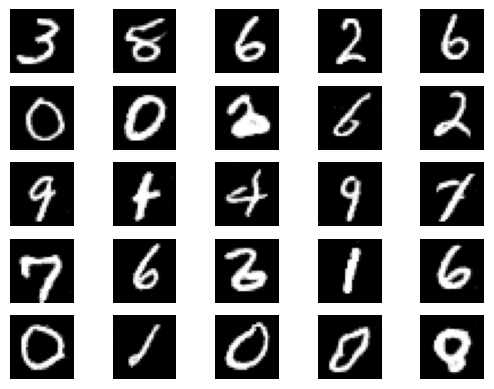

In [10]:
batch_size = 25
latent_size = 100

fixed_noise: torch.Tensor = torch.randn(batch_size, latent_size, 1, 1).to(device)
fake_images: torch.Tensor = netG(fixed_noise)
fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 28, 28)
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.axis('off')
    plt.imshow(fake_images_np[i], cmap='gray')
plt.show()

## 顯示 GIF 檔

In [11]:
# 安裝產生 GIF 檔的套件
!pip install -q imageio

In [12]:
# 產生 GIF 檔
anim_file = 'gan_output/dcgan.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('gan_output/fake_samples*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        cast(imageio.core.format.Format.Writer, writer).append_data(image)

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_30753/3203839463.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


<img src="gan_output/dcgan.gif" align="left">

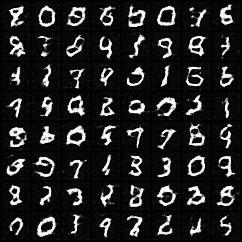

In [ ]:
# 顯示anim_file圖檔，並能循環播放
display(Image(filename=anim_file))